# 13 — Comparación de métodos entre tareas

Reúne, para cada tarea implementada, los cuatro métodos tabulares con el mismo protocolo dentro de cada tarea:
mismos estados, acciones, presupuesto, semillas (0–4) e inicios de evaluación; solo cambia la regla de
actualización. Métrica común: **media de las últimas 5 evaluaciones greedy** (robusta a la oscilación de la
conducción), con IC 95 % bootstrap sobre semillas. Una diferencia se declara solo si los IC no se solapan.

| tarea | éxito | presupuesto | α | fuente |
|---|---|---|---|---|
| Persecución (kit, [5, 40] m) | captura en < 40 pasos | 80 000 | 0.1 para todos (sin barrido) | `runs_kit_final_algorithms`, `runs_kit_final` (notebook 07) |
| Tiro a puerta (con arquero) | gol | 50 000 | barrido con ε decreciente | `runs_shooting` (notebook 10) |
| Conducción (36 estados) | avance de 30 m | 60 000 | barrido por esquema | `runs_dribbling` (notebook 11) |
| Cooperación 2v1 (324 estados) | posesión > 50 pasos y ≥ 3 pases | 60 000 | barrido por esquema | `runs_passing` (notebook 12) |

Las explicaciones de cada diferencia están en los
notebooks de cada tarea, junto al diagnóstico que las respalda.

In [1]:
import os, json, glob
import numpy as np
from IPython.display import display, Markdown
os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src.task_analysis import bootstrap_ci

ART = "notebooks/artifacts"
METHODS = ["qlearning", "sarsa", "mc_first_visit", "mc_first_visit_alpha"]
METHOD_ES = {"qlearning": "Q-Learning", "sarsa": "SARSA", "mc_first_visit": "MC (promedio)",
             "mc_first_visit_alpha": "MC (α constante)"}

def stats(values):
    v = np.asarray(values, float)
    return {"mean": float(v.mean()), "ci95": bootstrap_ci(v), "per_seed": v.tolist()}

def pursuit(cond_dir):
    last5, auc = [], []
    for f in sorted(glob.glob(f"{cond_dir}/seed_*/eval.json")):
        ev = [e["capture_rate_lt40"] for e in json.load(open(f))["evals"]]
        last5.append(np.mean(ev[-5:])); auc.append(np.mean(ev))
    return {"last5_mean": stats(last5), "auc": stats(auc)}

def task(summary, name, variant):
    v = summary[name]["variants"][variant]
    return {"last5_mean": stats(v["last5_mean"]["per_seed"]), "auc": stats(v["auc"]["per_seed"])}

shoot = json.load(open(f"{ART}/shooting_summary.json"))["conditions"]
drib = json.load(open(f"{ART}/dribbling_summary.json"))["conditions"]
pas = json.load(open(f"{ART}/passing_summary.json"))["conditions"]
table = {"decay": {}, "constant": {}}
table["decay"]["Persecución"] = {m: pursuit(f"{ART}/runs_kit_final_algorithms/kit_algo_{m}") for m in METHODS}
table["constant"]["Persecución"] = {"qlearning": pursuit(f"{ART}/runs_kit_final/kit_qlearning_eps_const_0.1")}
for sched, tag in (("decay", "eps_decay_1_to_0.1"), ("constant", "eps_const_0.1")):
    table[sched]["Tiro a puerta"] = {m: task(shoot, f"shooting_{m}_{tag}", "keeper") for m in METHODS}
    table[sched]["Conducción"] = {m: task(drib, f"dribbling_{m}_{tag}", "default") for m in METHODS}
    table[sched]["Cooperación 2v1"] = {m: task(pas, f"passing_{m}_{tag}", "default") for m in METHODS}
json.dump({"metric": "mean of the last 5 greedy evaluations (success); auc = mean over all evaluations",
           "ci": "95% percentile bootstrap over the 5 training seeds", "table": table},
          open(f"{ART}/comparison_summary.json", "w"), indent=2, ensure_ascii=False)

## Tabla principal: $\varepsilon$ decreciente

En negrita, el mejor método de cada tarea y los que no se distinguen de él (IC solapados).

In [2]:
def render(sched, metric="last5_mean"):
    rows = ["| tarea | " + " | ".join(METHOD_ES[m] for m in METHODS) + " |", "|---|---|---|---|---|"]
    for t, cells in table[sched].items():
        best = max(cells.values(), key=lambda c: c[metric]["mean"])[metric]
        out = []
        for m in METHODS:
            if m not in cells:
                out.append("—"); continue
            s = cells[m][metric]
            txt = f"{100 * s['mean']:.1f} [{100 * s['ci95'][0]:.1f}, {100 * s['ci95'][1]:.1f}]"
            tie = not (s["ci95"][1] < best["ci95"][0] or best["ci95"][1] < s["ci95"][0])
            out.append(f"**{txt}**" if tie else txt)
        rows.append(f"| {t} | " + " | ".join(out) + " |")
    return "\n".join(rows)
display(Markdown("**Éxito, media de las últimas 5 evaluaciones (%):**\n\n" + render("decay")))
display(Markdown("**AUC: éxito medio a lo largo del entrenamiento (%), mayor = aprende antes:**\n\n" + render("decay", "auc")))

**Éxito, media de las últimas 5 evaluaciones (%):**

| tarea | Q-Learning | SARSA | MC (promedio) | MC (α constante) |
|---|---|---|---|---|
| Persecución | **84.7 [84.5, 85.1]** | **85.3 [84.8, 85.8]** | **85.3 [84.4, 86.1]** | 45.8 [41.6, 50.1] |
| Tiro a puerta | **92.2 [91.7, 92.6]** | **92.2 [91.7, 92.7]** | **92.8 [92.4, 93.4]** | **91.8 [90.6, 92.5]** |
| Conducción | **97.7 [96.3, 99.0]** | **94.3 [89.8, 97.7]** | **90.4 [79.0, 98.9]** | 30.1 [16.3, 45.7] |
| Cooperación 2v1 | **64.8 [61.3, 68.1]** | 54.2 [51.0, 56.1] | 7.8 [2.9, 14.9] | 20.7 [9.8, 31.5] |

**AUC: éxito medio a lo largo del entrenamiento (%), mayor = aprende antes:**

| tarea | Q-Learning | SARSA | MC (promedio) | MC (α constante) |
|---|---|---|---|---|
| Persecución | 77.0 [76.6, 77.4] | **83.3 [82.8, 83.9]** | **84.3 [83.1, 85.3]** | 43.2 [41.9, 44.6] |
| Tiro a puerta | 90.9 [90.2, 91.6] | 90.5 [89.8, 91.1] | **92.6 [92.1, 93.0]** | 90.0 [89.3, 90.7] |
| Conducción | **92.4 [90.5, 94.3]** | 76.2 [73.5, 79.9] | 70.8 [57.6, 80.5] | 22.3 [18.9, 26.6] |
| Cooperación 2v1 | **44.9 [42.5, 46.5]** | 28.2 [25.3, 30.2] | 2.6 [1.5, 3.6] | 9.2 [4.8, 14.2] |

## $\varepsilon$ constante 0.1

En la persecución solo Q-Learning se entrenó con $\varepsilon$ constante (la ablación del notebook 07).

In [3]:
display(Markdown(render("constant")))

| tarea | Q-Learning | SARSA | MC (promedio) | MC (α constante) |
|---|---|---|---|---|
| Persecución | **84.9 [84.4, 85.4]** | — | — | — |
| Tiro a puerta | 86.6 [85.1, 88.1] | 86.5 [85.0, 88.0] | **93.2 [92.6, 93.7]** | 86.0 [84.3, 87.5] |
| Conducción | 89.7 [83.8, 95.5] | **96.8 [95.8, 97.8]** | 70.6 [52.0, 87.6] | 18.8 [7.1, 33.8] |
| Cooperación 2v1 | **65.5 [64.2, 67.4]** | 54.2 [51.9, 56.3] | 26.1 [18.0, 39.9] | 16.7 [6.8, 27.6] |

## Lectura

- **Persecución** (determinista, recompensa densa, sin riesgo): al final, Q-Learning, SARSA y MC con promedios no
  se distinguen; el techo lo pone la representación (óptimo exacto 87.9 %, notebook 07), no la regla de
  actualización. SARSA y MC con promedios aprenden antes que Q-Learning (AUC).
- **Tiro a puerta** (casi una sola decisión, resultado estocástico): con ε decreciente los cuatro terminan igual;
  MC con promedios aprende antes (AUC) y es el único que no se retrasa con ε constante. Q-Learning y SARSA son
  idénticos por construcción (los tiros son terminales). Diagnóstico: notebook 10, §7.
- **Conducción** (determinista, episodios largos, estados agregados): con ε decreciente, Q-Learning, SARSA y MC
  con promedios no se distinguen al final (el IC de MC es muy ancho, 79–99 %), pero Q-Learning aprende mucho antes
  (AUC). Con ε constante, SARSA es el mejor. Con 36 estados, MC con promedios congela su política en algunas
  semillas; con 245 estados llega a 97.8 %, y Q-Learning y SARSA a 100 %. Diagnóstico: notebook 11, §8.
- **Cooperación 2v1** (estocástica, 60 pasos, riesgo de quite): Q-Learning es el mejor con ambas exploraciones y
  aprende antes; SARSA queda unos 11 puntos atrás y los dos MC fallan (MC con promedios termina la mayoría de los
  episodios con un despeje). SARSA no fue más prudente que Q-Learning pese al riesgo real. Diagnóstico: notebook 12, §8.
- **MC** (ambas variantes) falla en la cooperación 2v1, y MC con α constante también en la persecución y la
  conducción: en las tres tareas de episodios largos. Solo funciona bien en el tiro a puerta, de un paso. La causa
  no está aislada.

## Figuras del informe

Figuras comunes a las cuatro tareas: curvas de aprendizaje (A), comparación de métodos (B), política y valor del
tiro frente al óptimo exacto (D), trayectorias al inicio y al final del entrenamiento (E) y diagnósticos (F). La
política y el valor de la persecución (C) vienen del notebook 07.

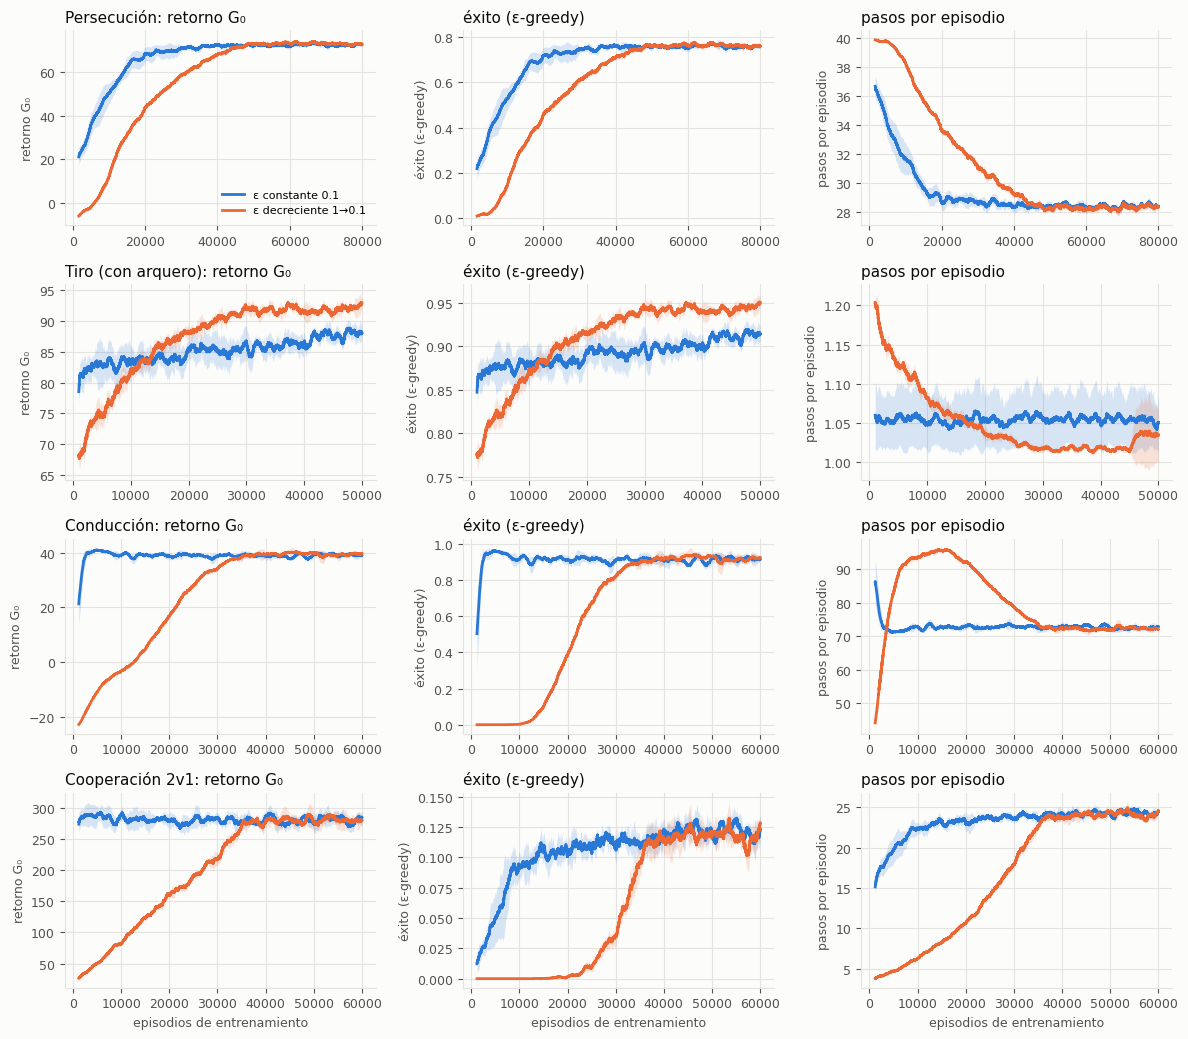

In [4]:
import matplotlib.pyplot as plt
from src import plots, shooting_env as se, dribbling_env as de, passing_env as pe
from src.task_analysis import load_condition
from src.task_train import get_task, run_episode
from src.agents import AGENTS
from src.discretizer import Discretizer
from src.train import KIT_DISCRETIZATIONS
from src.sampler import evaluation_starts as pursuit_starts

TASK = {  # name: (runs dir prefix, schedule tags (const, decay), success key, eval metric getter, reference)
    "Persecución": (f"{ART}/runs_kit_final/kit_qlearning_", ("eps_const_0.1", "eps_decay_1.0_to_0.1"), "captured"),
    "Tiro (con arquero)": (f"{ART}/runs_shooting/shooting_qlearning_", ("eps_const_0.1", "eps_decay_1_to_0.1"), "success"),
    "Conducción": (f"{ART}/runs_dribbling/dribbling_qlearning_", ("eps_const_0.1", "eps_decay_1_to_0.1"), "success"),
    "Cooperación 2v1": (f"{ART}/runs_passing/passing_qlearning_", ("eps_const_0.1", "eps_decay_1_to_0.1"), "success"),
}
SCHED = {0: "ε constante 0.1", 1: "ε decreciente 1→0.1"}
COLS = ["qlearning", "sarsa", "mc_first_visit", "mc_first_visit_alpha"]

# (A) training curves: G0, success, steps
fig, axes = plt.subplots(4, 3, figsize=(12, 10.5))
for r, (name, (prefix, tags, skey)) in enumerate(TASK.items()):
    runs = {SCHED[i]: load_condition(prefix + t) for i, t in enumerate(tags)}
    n = runs[SCHED[0]][0]["config"]["n_episodes"]
    for c, (key, lab) in enumerate((("discounted_return", "retorno G₀"), (skey, "éxito (ε-greedy)"),
                                    ("steps", "pasos por episodio"))):
        ax = axes[r, c]
        plots.plot_training_curve(runs, key, window=max(500, n // 50), ax=ax, ylabel=lab,
                                  title=f"{name}: {lab}" if c == 0 else lab, direct_labels=False)
        if not (r == 0 and c == 0):
            ax.get_legend().remove()
        if r < 3:
            ax.set_xlabel("")
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(f"{ART}/fig_report_curves.png", dpi=170, bbox_inches="tight"); plt.show()

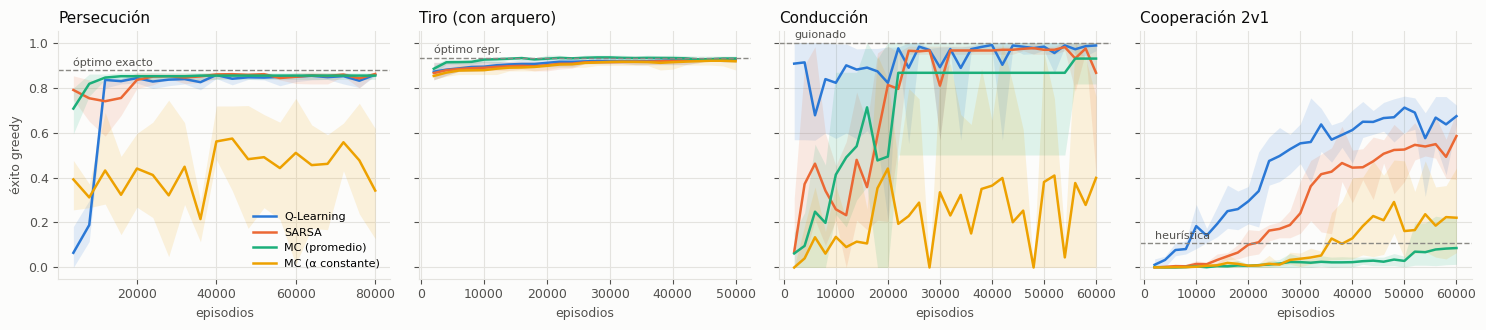

In [5]:
# (B) greedy success of the four methods, decaying epsilon
MCOL = {"qlearning": plots.SERIES[0], "sarsa": plots.SERIES[1], "mc_first_visit": plots.SERIES[2],
        "mc_first_visit_alpha": plots.SERIES[3]}
def curves(task, m):
    if task == "Persecución":
        rs = load_condition(f"{ART}/runs_kit_final_algorithms/kit_algo_{m}")
        return rs[0]["evals"], np.array([[e["capture_rate_lt40"] for e in r["evals"]] for r in rs])
    d, v = {"Tiro (con arquero)": ("shooting", "keeper"), "Conducción": ("dribbling", "default"),
            "Cooperación 2v1": ("passing", "default")}[task]
    rs = load_condition(f"{ART}/runs_{d}/{d}_{m}_eps_decay_1_to_0.1")
    return rs[0]["evals"], np.array([[e["variants"][v]["success_rate"] for e in r["evals"]] for r in rs])
REF = {"Persecución": ("óptimo exacto", 0.879), "Tiro (con arquero)": ("óptimo repr.", 0.933),
       "Conducción": ("guionado", 1.0), "Cooperación 2v1": ("heurística", 0.108)}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for ax, task in zip(axes, TASK):
    for m in COLS:
        ev, ys = curves(task, m)
        x = [e["episode"] for e in ev]
        ax.fill_between(x, ys.min(0), ys.max(0), color=MCOL[m], alpha=0.13, linewidth=0)
        ax.plot(x, ys.mean(0), color=MCOL[m], linewidth=1.8, label=METHOD_ES[m])
    lab, y = REF[task]
    ax.axhline(y, color=plots.REF, linestyle="--", linewidth=1)
    ax.annotate(lab, (x[0], y), xytext=(0, 3), textcoords="offset points", fontsize=8, color=plots.TEXT_2)
    plots.style(ax, task, "episodios", "éxito greedy" if task == "Persecución" else "")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(f"{ART}/fig_report_methods.png", dpi=170, bbox_inches="tight"); plt.show()

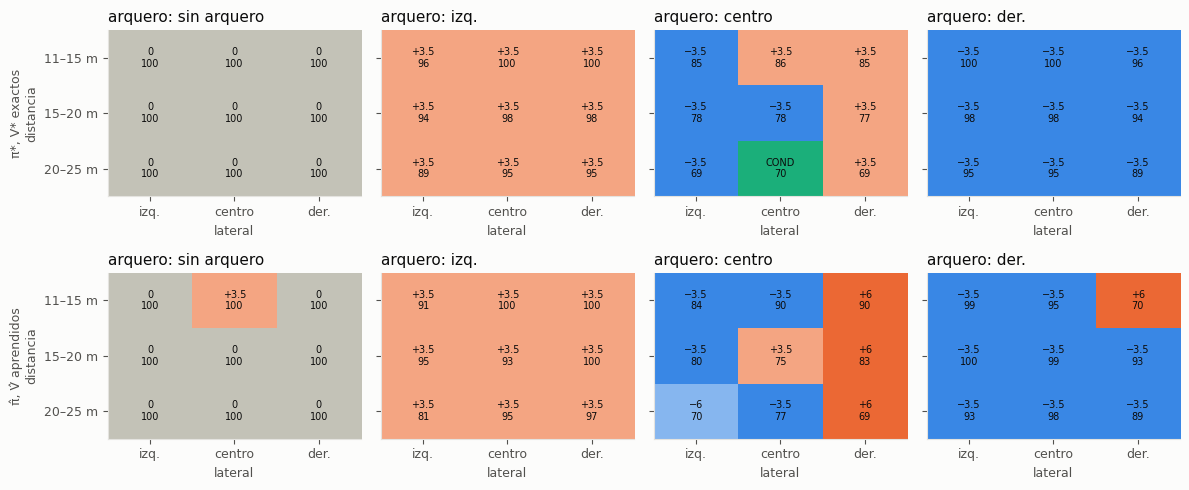

In [6]:
# (D) shooting: learned greedy policy and V̂ (Q-Learning, decaying eps, seed 0) vs the exact representation optimum
opt = json.load(open(f"{ART}/shooting_optimal.json"))
sd = se.default_discretizer()
Qs = load_condition(f"{ART}/runs_shooting/shooting_qlearning_eps_decay_1_to_0.1")[0]["Q"]
SHORT = ["−6", "−3.5", "0", "+3.5", "+6", "COND"]
ACOL = ["#86b6ef", "#3987e5", "#c3c2b7", "#f4a582", "#eb6834", "#1baf7a"]
NAMES = {"d_g": "distancia", "y": "lateral", "keeper": "arquero"}
fig, axes = plt.subplots(2, 4, figsize=(12, 5.0))
plots.plot_policy_grid(np.array(opt["representation_policy_actions"]), sd, "d_g", "y", "keeper", SHORT, ACOL,
                       values=np.array([np.nan if v is None else v for v in opt["representation_start_values"]]),
                       names=NAMES, axes=list(axes[0]), fontsize=7)
plots.plot_policy_grid(Qs.argmax(1), sd, "d_g", "y", "keeper", SHORT, ACOL, values=Qs.max(1), names=NAMES,
                       axes=list(axes[1]), fontsize=7)
axes[0, 0].set_ylabel("π*, V* exactos\ndistancia", fontsize=9)
axes[1, 0].set_ylabel("π̂, V̂ aprendidos\ndistancia", fontsize=9)
fig.tight_layout(); fig.savefig(f"{ART}/fig_report_shooting_policy.png", dpi=170, bbox_inches="tight"); plt.show()

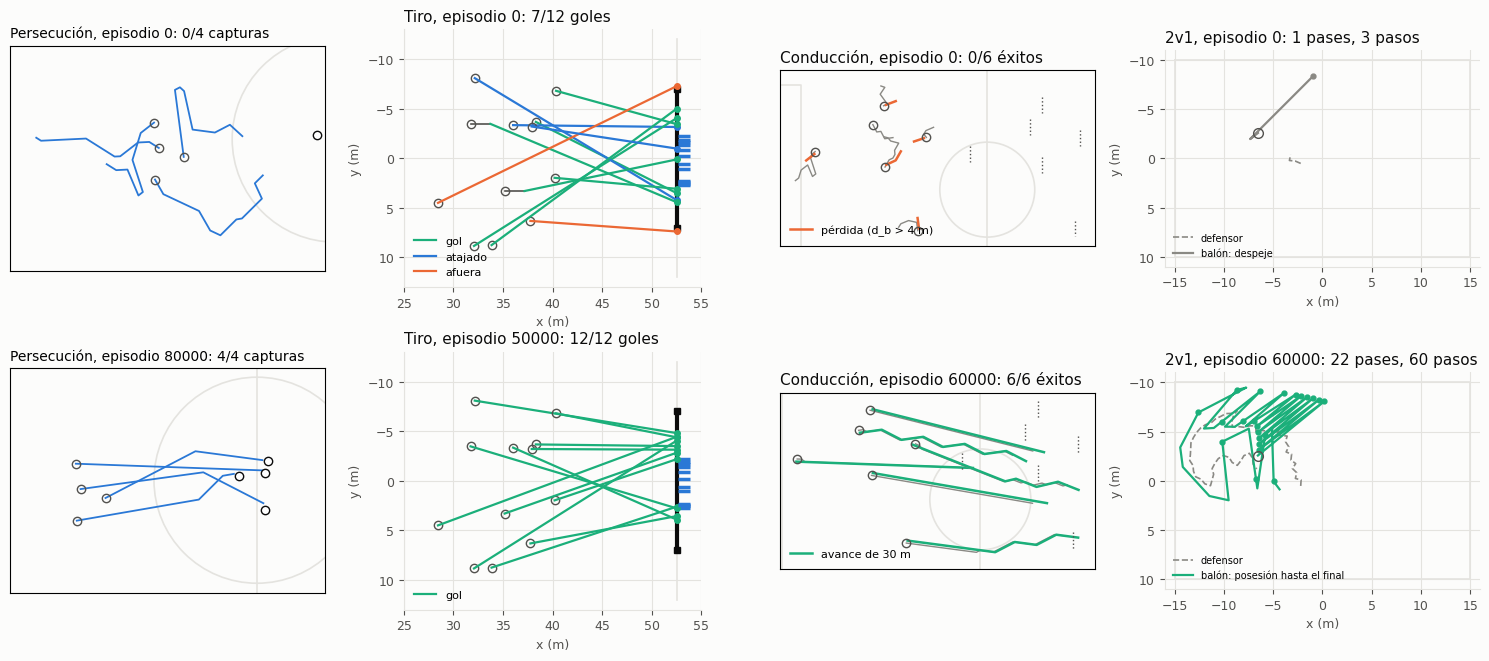

In [7]:
# (E) greedy behaviour at the start (episode 0) and the end of training, Q-Learning decaying eps, seed 0
def snaps(path):
    return np.load(f"{path}/q_snapshots.npz")
fig, axes = plt.subplots(2, 4, figsize=(15, 6.6))
# pursuit
ps = get_task("pursuit_kit"); pdisc = Discretizer(KIT_DISCRETIZATIONS["R3"])
from src.kit_env import KitBallPursuitEnv
psn = snaps(f"{ART}/runs_kit_final/kit_qlearning_eps_decay_1.0_to_0.1/seed_0")
pstart = pursuit_starts(500, 12345, law="kit")[:4]
for row, key in enumerate(("ep_0", "ep_80000")):
    ax = axes[row, 0]; plots.draw_pitch(ax, light=True)
    ag = AGENTS["qlearning"](pdisc.n_states, 4, seed=0); ag.Q = psn[key].copy()
    env = KitBallPursuitEnv(seed=0); ok = 0; xs, ys = [], []
    for st in pstart:
        rec = run_episode(ps, env, ag, pdisc, 0.0, learn=False, start=st, record=True)
        px = [t["player"][0] for t in rec["trajectory"]]; py = [t["player"][1] for t in rec["trajectory"]]
        ax.plot(px, py, color=plots.SERIES[0], linewidth=1.3); ax.plot(px[0], py[0], "o", color=plots.TEXT_2, mfc="none")
        bx, by = rec["trajectory"][0]["ball"]; ax.plot(bx, by, "o", color="white", mec=plots.TEXT, ms=6)
        ok += rec["success"]; xs += px + [bx]; ys += py + [by]
    cx, cy = np.mean(xs), np.mean(ys)
    ax.set_xlim(cx - 14, cx + 14); ax.set_ylim(cy + 10, cy - 10)
    ax.set_title(f"Persecución, episodio {key[3:]}: {ok}/4 capturas", fontsize=10, loc="left")
# shooting
ss = get_task("shooting"); ssn = snaps(f"{ART}/runs_shooting/shooting_qlearning_eps_decay_1_to_0.1/seed_0")
sst = se.evaluation_starts(500, 12345, "keeper")[:12]
for row, key in enumerate(("ep_0", "ep_50000")):
    ag = AGENTS["qlearning"](sd.n_states, 6, seed=0); ag.Q = ssn[key].copy()
    env = se.ShootingEnv(seed=0); env.rng = np.random.default_rng(7)
    recs = [run_episode(ss, env, ag, sd, 0.0, learn=False, start=st, record=True) for st in sst]
    plots.plot_shooting_episodes(recs, ax=axes[row, 1], show_reach=False,
                                 title=f"Tiro, episodio {key[3:]}: {sum(r['success'] for r in recs)}/12 goles")
# dribbling
ds = get_task("dribbling"); ddisc = de.default_discretizer()
dsn = snaps(f"{ART}/runs_dribbling/dribbling_qlearning_eps_decay_1_to_0.1/seed_0")
dst = de.evaluation_starts(500, 12345)[:6]
for row, key in enumerate(("ep_0", "ep_60000")):
    ag = AGENTS["qlearning"](ddisc.n_states, 4, seed=0); ag.Q = dsn[key].copy()
    env = de.DribblingEnv(seed=0)
    recs = [run_episode(ds, env, ag, ddisc, 0.0, learn=False, start=st, record=True) for st in dst]
    plots.plot_dribbling_episodes(recs, ax=axes[row, 2],
                                  title=f"Conducción, episodio {key[3:]}: {sum(r['success'] for r in recs)}/6 éxitos")
# 2v1
qs = get_task("passing"); qdisc = pe.default_discretizer()
qsn = snaps(f"{ART}/runs_passing/passing_qlearning_eps_decay_1_to_0.1/seed_0")
qst = pe.evaluation_starts(500, 12345)[0]
for row, key in enumerate(("ep_0", "ep_60000")):
    ag = AGENTS["qlearning"](qdisc.n_states, 4, seed=0); ag.Q = qsn[key].copy()
    env = pe.PassingEnv(seed=0); env.rng = np.random.default_rng(5)
    rec = run_episode(qs, env, ag, qdisc, 0.0, learn=False, start=qst, record=True)
    plots.plot_passing_episode(rec, ax=axes[row, 3],
                               title=f"2v1, episodio {key[3:]}: {rec['passes']} pases, {rec['possession']} pasos")
for ax in axes.flat:
    ax.title.set_fontsize(10)
fig.tight_layout(); fig.savefig(f"{ART}/fig_report_trajectories.png", dpi=170, bbox_inches="tight"); plt.show()

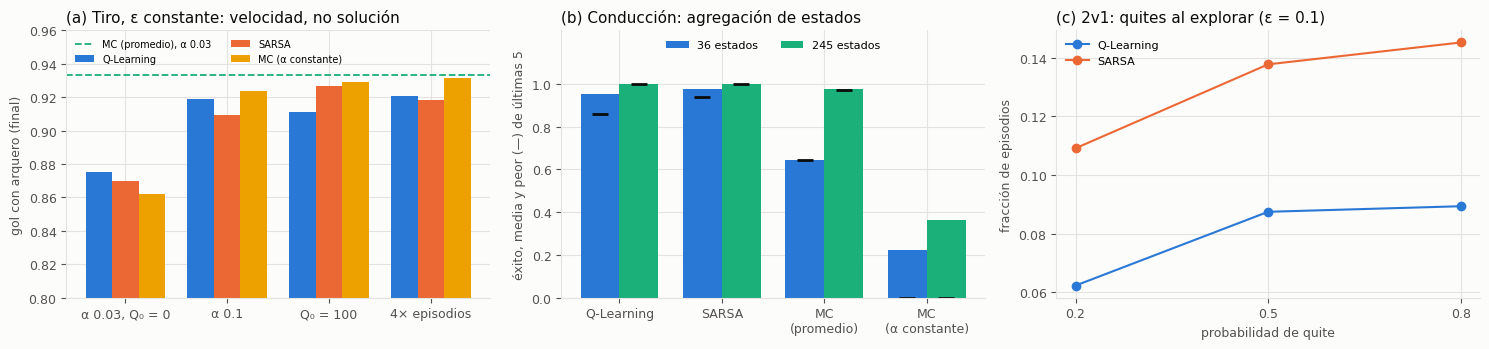

In [8]:
# (F) diagnostics behind the method differences
shs = json.load(open(f"{ART}/shooting_summary.json"))["conditions"]
drs = json.load(open(f"{ART}/dribbling_summary.json"))["conditions"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
ax = axes[0]; conds = [("α 0.03, Q₀ = 0", "shooting_{m}_eps_const_0.1"), ("α 0.1", "shooting_diag_step_{m}_alpha0.1"),
                       ("Q₀ = 100", "shooting_diag_optinit_{m}"), ("4× episodios", "shooting_diag_budget4x_{m}")]
ms = ["qlearning", "sarsa", "mc_first_visit_alpha"]; w = 0.26
for j, m in enumerate(ms):
    v = [shs[c.format(m=m)]["variants"]["keeper"]["final"]["mean"] for _, c in conds]
    ax.bar(np.arange(4) + (j - 1) * w, v, width=w, color=MCOL[m], label=METHOD_ES[m])
ax.axhline(shs["shooting_mc_first_visit_eps_const_0.1"]["variants"]["keeper"]["final"]["mean"], color=MCOL["mc_first_visit"],
           linestyle="--", linewidth=1.3, label="MC (promedio), α 0.03")
ax.set_xticks(range(4), [c for c, _ in conds], fontsize=8); ax.set_ylim(0.8, 0.96)
plots.style(ax, "(a) Tiro, ε constante: velocidad, no solución", "", "gol con arquero (final)")
ax.legend(frameon=False, fontsize=7, loc="upper left", ncol=2)
ax = axes[1]; w = 0.38
for j, (rep, name, color) in enumerate((("default", "36 estados", plots.SERIES[0]), ("fine", "245 estados", plots.SERIES[2]))):
    means = [drs[f"dribbling_diag_rep_{rep}_{m}"]["variants"]["default"]["last5_mean"]["mean"] for m in COLS]
    worst = [drs[f"dribbling_diag_rep_{rep}_{m}"]["variants"]["default"]["last5_worst"]["mean"] for m in COLS]
    xs = np.arange(len(COLS)) + (j - 0.5) * w
    ax.bar(xs, means, width=w, color=color, label=name)
    ax.plot(xs, worst, "_", color=plots.TEXT, markersize=12, markeredgewidth=2)
ax.set_xticks(range(len(COLS)), [METHOD_ES[m].replace(" (", "\n(") for m in COLS], fontsize=8)
ax.set_ylim(0, 1.25); ax.set_yticks(np.arange(0, 1.01, 0.2))
plots.style(ax, "(b) Conducción: agregación de estados", "", "éxito, media y peor (—) de últimas 5")
ax.legend(frameon=False, fontsize=8, loc="upper center", ncol=2)
ax = axes[2]
def tackles(path):
    rs = load_condition(path); t = rs[0]["config"]["n_episodes"] // 10
    return np.mean([np.mean(r["history"]["outcome"][-t:] == pe.TACKLED) for r in rs])
ps_ = (0.2, 0.5, 0.8)
for m in ("qlearning", "sarsa"):
    paths = [f"{ART}/runs_passing_diag/passing_diag_tackle0.2_{m}", f"{ART}/runs_passing/passing_{m}_eps_const_0.1",
             f"{ART}/runs_passing_diag/passing_diag_tackle0.8_{m}"]
    ax.plot(ps_, [tackles(p) for p in paths], "o-", color=MCOL[m], label=METHOD_ES[m])
ax.set_xticks(ps_)
plots.style(ax, "(c) 2v1: quites al explorar (ε = 0.1)", "probabilidad de quite", "fracción de episodios")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout(); fig.savefig(f"{ART}/fig_report_diagnostics.png", dpi=170, bbox_inches="tight"); plt.show()